# Concrete Crack & Fatigue Detection | ResNet50

This notebook implements the visual modality component of a multimodal structural crack detection system. The objective of this stage is to train a deep convolutional neural network capable of distinguishing between cracked and non-cracked concrete surfaces. The dataset used contains thousands of labeled images of concrete structures, making it suitable for supervised image classification tasks. A transfer learning approach is adopted using a pretrained ResNet50 architecture, which has already learned rich visual features from large-scale datasets. By fine-tuning this network on the crack detection dataset, the model can efficiently learn crack patterns such as edges, fractures, and surface discontinuities while significantly reducing training time and computational requirements.

## Device Configuration & Packages Installation

Before building and training the neural network, the notebook first prepares the working environment by importing the necessary libraries, configuring the computation device, and defining the dataset paths. The imported libraries provide functionality for deep learning, image processing, numerical computation, and visualization. PyTorch and torchvision are used for constructing and training the neural network model, while libraries such as NumPy, Matplotlib, and Seaborn assist with data handling and result visualization. The device configuration ensures that the model utilizes GPU acceleration if available, significantly improving training speed. Finally, the dataset directory paths are defined so that the concrete crack image dataset can be correctly accessed and loaded within the Kaggle environment.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU count:", torch.cuda.device_count())

Using device: cuda
GPU count: 2


In [22]:
dataset_path = "/kaggle/input/datasets/arnavr10880/concrete-crack-images-for-classification"

negative_path = os.path.join(dataset_path, "Negative")
positive_path = os.path.join(dataset_path, "Positive")

print("Negative images:", len(os.listdir(negative_path)))
print("Positive images:", len(os.listdir(positive_path)))

Negative images: 20000
Positive images: 20000


## Image Preprocessing and Data Augmentation

Before training the neural network, the images must be transformed into a format suitable for the pretrained model. ResNet50 expects images of size 224×224 pixels, so the images are resized accordingly. The images are then converted into tensors and normalized using the standard ImageNet normalization values, which ensures compatibility with the pretrained weights. Additionally, a simple augmentation technique, random horizontal flipping—is applied to introduce variability in the training data. Data augmentation helps the model generalize better by exposing it to slightly altered versions of the same images, reducing the risk of overfitting.

In [23]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

## Data Loading

This section loads the dataset using PyTorch’s ImageFolder class, which automatically assigns labels to images based on their directory structure. Each subfolder corresponds to a class label, making it convenient to organize classification datasets. The transformation pipeline defined earlier is applied to every image as it is loaded. After loading the dataset, the class names and the total number of images are displayed. This step confirms that the dataset has been correctly parsed and provides an overview of the dataset size before splitting it into training and validation sets.

In [24]:
dataset = datasets.ImageFolder(dataset_path, transform=transform)

class_names = dataset.classes
print("Classes:", class_names)
print("Total images:", len(dataset))

Classes: ['Negative', 'Positive']
Total images: 40000


## Train / Validation Split
Machine learning models should be evaluated on data that was not used during training to measure how well they generalize to unseen examples. To achieve this, the dataset is divided into training and validation subsets. The training subset is used to update the model weights, while the validation subset is used to evaluate performance during development. In this notebook, an 80–20 split is used, where 80% of the data is allocated for training and the remaining 20% for validation. This is a common practice in deep learning workflows and provides a reliable estimate of model performance.

In [25]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 32000
Validation size: 8000


## Model Initialization & Training Configuration

After preparing the dataset and splitting it into training and validation subsets, the next step is to configure the components required for model training. DataLoaders are first created to efficiently feed batches of images to the neural network during training and evaluation. Batching improves memory efficiency and allows the model to learn from multiple samples simultaneously. Next, a pretrained ResNet50 model is loaded using transfer learning, and its final fully connected layer is modified to perform binary classification for crack detection. Finally, the training setup is completed by defining the CrossEntropyLoss function and the Adam optimizer, which together guide the learning process and update model parameters during training.

In [26]:
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

torch.backends.cudnn.benchmark = True

Using 2 GPUs


## Training Loop

This section implements the main training loop for the neural network. During each epoch, the model processes batches of images from the training dataset, computes predictions, and calculates the loss using the defined loss function. Gradients are then computed using backpropagation, and the optimizer updates the model parameters accordingly. The training loss is accumulated for each epoch and stored for later visualization. Running multiple epochs allows the model to progressively learn the visual patterns associated with cracked and non-cracked concrete surfaces.

In [27]:
epochs = 10
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f}")

if isinstance(model, torch.nn.DataParallel):
    torch.save(model.module.state_dict(), "/kaggle/working/resnet50_crack_model.pth")
else:
    torch.save(model.state_dict(), "/kaggle/working/resnet50_crack_model.pth")

print("Model saved successfully to /kaggle/working/")

100%|██████████| 125/125 [16:23<00:00,  7.87s/it]


Epoch 1/1
Train Loss: 0.0198
Val Loss: 0.0045
Model saved successfully to /kaggle/working/


## Model Evaluation

Once training is complete, the model must be evaluated on the validation dataset to assess its generalization performance. During evaluation, gradient computation is disabled to improve efficiency. The model processes each batch of validation images and produces predicted class labels. These predictions are stored along with the ground truth labels so that evaluation metrics can be computed in the next section. This process provides a clear indication of how well the model performs on unseen data.

In [28]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

## Model Evaluation and Performance Visualization

After training the ResNet50 model, it is important to evaluate how well the model performs on unseen data. This section computes multiple evaluation metrics and visualizations that help assess the classification performance of the trained network. The model is first evaluated on the validation dataset to compute the validation loss, which provides insight into how well the model generalizes beyond the training data. Predictions are then collected to calculate key classification metrics such as accuracy, precision, recall, and F1-score. Additionally, a confusion matrix is generated to visualize prediction errors between cracked and non-cracked classes. Finally, training and validation loss curves are plotted to analyze the learning behavior of the model across epochs.

Validation Loss: 0.004677400502259843
Accuracy: 0.998625
Precision: 0.9984863773965691
Recall: 0.998738329548322
F1 Score: 0.9986123375804213

Detailed Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4037
    Positive       1.00      1.00      1.00      3963

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



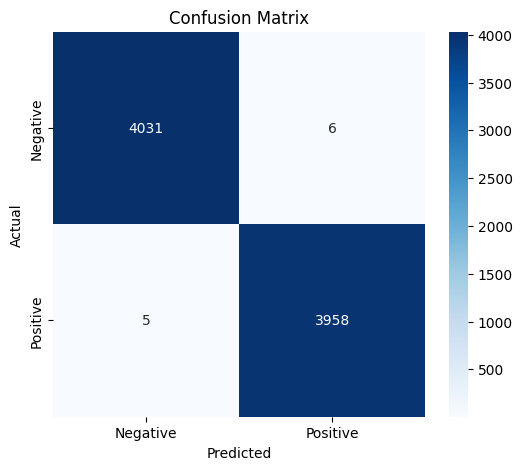

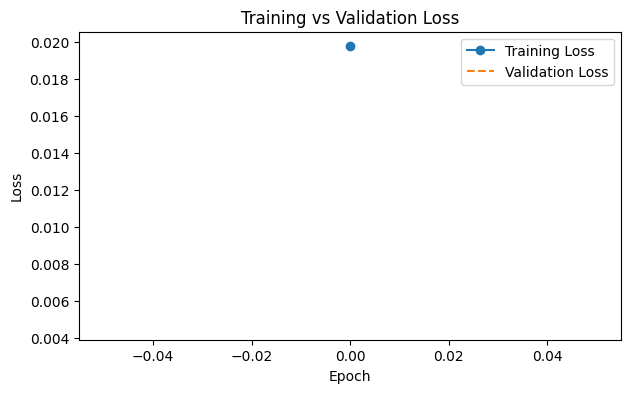

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

model.eval()

val_losses = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_losses.append(loss.item())
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Evaluation Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Validation Loss:", np.mean(val_losses))
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nDetailed Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Training vs Validation Loss Curve
plt.figure(figsize=(7,4))
plt.plot(train_losses, label="Training Loss", marker='o')
plt.plot([np.mean(val_losses)]*len(train_losses), label="Validation Loss", linestyle="--")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Visualization of Sample Predictions

To better understand the behavior of the trained model, it is useful to visually inspect a few predictions made on unseen validation images. In this section, several samples are taken from the validation dataset and passed through the trained ResNet50 model to generate predictions. The predicted class labels are then compared with the ground truth labels and displayed alongside the corresponding images. This qualitative evaluation helps verify that the model is correctly identifying crack patterns and distinguishing them from non-cracked surfaces. Visualizing predictions also makes the results more interpretable and provides an intuitive demonstration of the model’s performance.

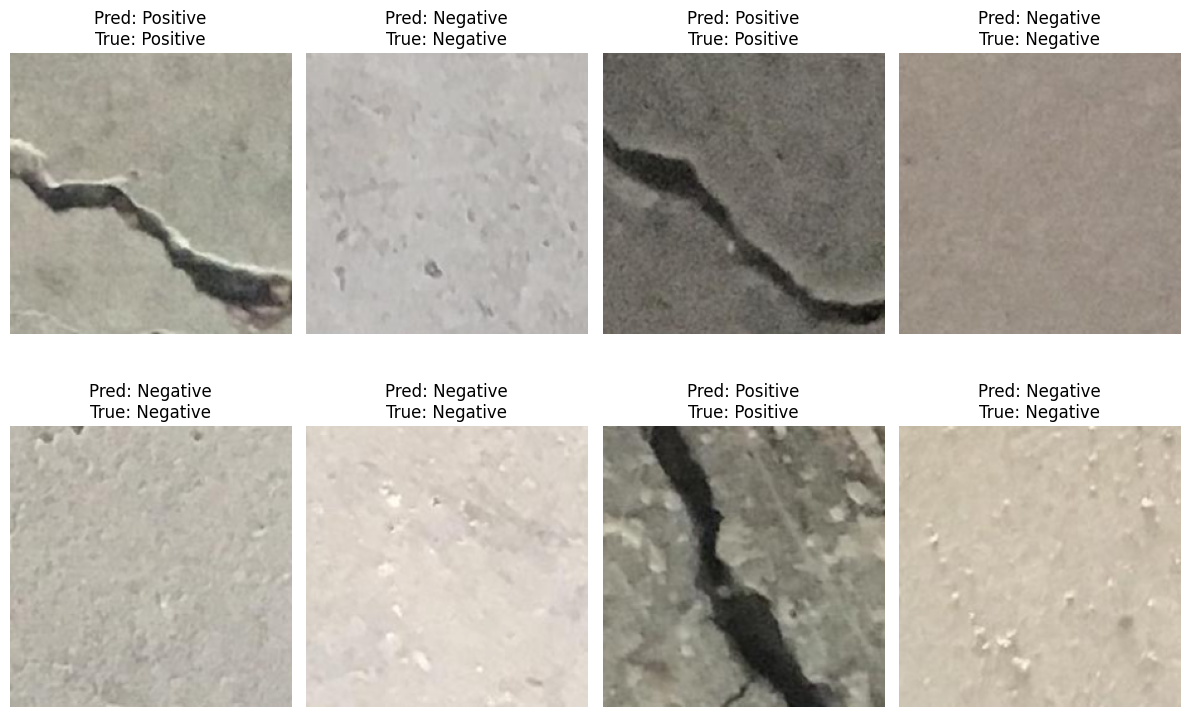

In [30]:
model.eval()
images_shown = 0
num_images = 8

plt.figure(figsize=(12,8))

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        images = images.cpu()
        for i in range(images.size(0)):
            if images_shown >= num_images:
                break
            img = images[i].permute(1,2,0).numpy()

            mean = np.array([0.485,0.456,0.406])
            std = np.array([0.229,0.224,0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            plt.subplot(2,4,images_shown+1)
            plt.imshow(img)
            plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}")
            plt.axis("off")
            images_shown += 1
        if images_shown >= num_images:
            break

plt.tight_layout()
plt.show()